In [36]:
import pandas as pd

#read dataset
#读取数据集
file_path = r'C:\Users\yuentolong\Dataset .csv'
df = pd.read_csv(file_path,encoding = 'latin-1')

#check out the data
#检查数据
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [37]:
#Clean the data and find out the cuisine combination of high rating
#清洗数据并且找出top10高评分菜品组合
from collections import Counter

#Clean the NaN and assign to a new dataframe
#清除空值并赋给新的dataframe
data = df[df['Cuisines'].notna()].copy()
#group the cuisine by comma
#将cuisines列以逗号分隔成组
data['cuisine_list'] = data['Cuisines'].str.split(',').apply(lambda x: sorted(x)) 
#Name a new hashable tuple
#命名新的可哈希元组
data['cuisine_combo'] = data['cuisine_list'].apply(tuple)
#Count the tuple
#对元组进行计数
combo_count = Counter(data['cuisine_combo'])

#Transform to dataframe,and key value as index,frequency as column
#转换成DataFrame，key值做索引，频率做列
combo_df = pd.DataFrame.from_dict(combo_count,orient = 'index',columns = ['Frequency'])
#Rename the index of tuple
#对元组的索引列重新进行命名
combo_df = combo_df.reset_index().rename(columns = {'index':'Cuisine Tuple'})
#Combina each element with '+' in the tuple
#对元组中每个元素都使用‘+’进行连接
combo_df['Cuisine Combination'] = combo_df['Cuisine Tuple'].apply(lambda x :' + '.join(x))

#Sort the tuple and print the top10
#排序并输出前10名
top10_common = combo_df.sort_values('Frequency',ascending = False).head(10)
top10_common

,Cuisine Tuple,Frequency,Cuisine Combination
342,"(North Indian,)",936,North Indian
378,"( Chinese, North Indian)",511,Chinese + North Indian
63,"(Fast Food,)",354,Fast Food
5,"(Chinese,)",354,Chinese
341,"( Mughlai, North Indian)",334,Mughlai + North Indian
20,"(Cafe,)",299,Cafe
344,"( Chinese, Mughlai, North Indian)",267,Chinese + Mughlai + North Indian
21,"(Bakery,)",218,Bakery
474,"( Desserts, Bakery)",170,Desserts + Bakery
388,"(Street Food,)",149,Street Food


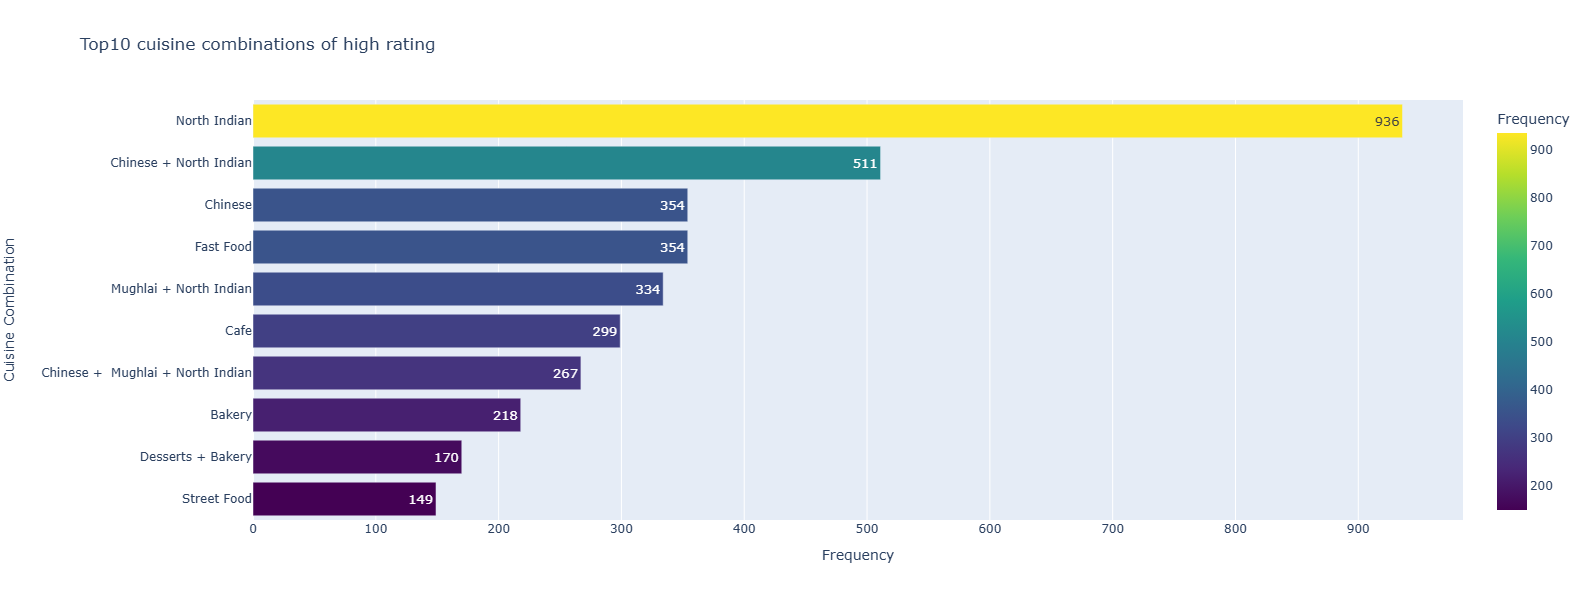

In [41]:
#Visualization for top10 cuisine combination of high rating
#可视化top10高评分菜品组合
import plotly.express as px

#Creating the bar
#绘制柱状图
fig = px.bar(
    top10_common,
    x = 'Frequency',
    y = 'Cuisine Combination',
    title = 'Top10 cuisine combinations of high rating',
    text = top10_common['Frequency'].astype(str),
    color = 'Frequency',
    color_continuous_scale = 'Viridis'
)

fig.update_traces(textposition = 'auto',textfont_size = 13)
fig.update_layout(
    yaxis = {'categoryorder': 'total ascending'},
    height = 600,
    width = 1400
)

fig.show()